# Calibration: CS-01 TAS apparatus

**Purpose**: characterise the host noise floor and the apparatus's rate ceiling under each deployment mode (`localhost`, `multiprocess`). Decides whether the host is fit to run an experimental method run; the verdict block in each envelope drives the pre-experiment gate.

**Inputs**:

- `data/config/method/experimental.json` (orchestrator + per-spawner runtime tuning).
- `data/config/method/prototype/calibration.json` (probe sample sizes + gate threshold; runtime fallbacks on the source side).

**Outputs**:

- Envelopes: `data/results/calibration/<dpl>/<host>_<run_id>.json` (one per dpl mode).
- Per-dpl figures: `data/img/calibration/<dpl>/{timer,jitter,loopback,handler_scaling,rate_sweep,summary}.{png,svg}`.
- Headline overlay: `data/img/calibration/comparison/overlay.{png,svg}`.

**Equivalent CLI**:

```bash
python -m src.methods.experimental --stage calibration --dpl localhost
python -m src.methods.experimental --stage calibration --dpl multiprocess
```


In [1]:
%matplotlib inline

from pathlib import Path

from src.experimental.procedure.deployment import Dpl
from src.methods.experimental import run_calibration
from src.view import (plot_calibration_summary,
                      plot_envelope_overlay,
                      plot_handler_scaling,
                      plot_jitter,
                      plot_loopback,
                      plot_rate_sweep,
                      plot_timer,
                      plot_workers_scaling)

# deployment-mode axis driven side-by-side
DPLS: list[Dpl] = ["localhost", "multiprocess"]

# figure output root for this method
IMG_ROOT = Path("data/img/calibration")

# Human-readable deployment-mode labels for plot titles / legends.
DISPLAY: dict[Dpl, str] = {
    "localhost": "Localhost",
    "multiprocess": "Multiprocess",
    "remote": "Remote",
}


## 1. Run calibration on every deployment mode

`run_calibration(dpl=...)` builds the envelope skeleton, runs the four host-floor probes (timer / jitter / loopback / handler scaling), brings up the vernier under the chosen deployment mode, drives the rate sweep at workers=1, runs the workers ramp on multiprocess, applies the gate verdict, and writes the envelope to `data/results/calibration/<dpl>/`.

**Why `n_clients = 8` in the JSON?** The workers ramp drives N worker processes from one Python driver. A single-process `httpx.AsyncClient` saturates around 1-1.5k req/s on Windows; past that, the *client* becomes the bottleneck and the probe mis-attributes "client busy" as "workers saturated". Eight client processes (one per ramp wave) push the client ceiling well above any worker count we'd realistically calibrate, so the recorded efficiency curve reflects worker-side scaling and not load-generator overhead. The client is deliberately overdimensioned: we want the host-vernier interaction to fail before the client does.

Takes ~1-3 minutes per deployment mode (the rate sweep + workers ramp dominate).


In [2]:
ENVELOPES = {}
for dpl in DPLS:
    print(f"\n=== Running calibration: dpl={dpl} ===")
    ENVELOPES[dpl] = run_calibration(dpl=dpl,
                                     framework="fastapi",
                                     write=True)



=== Running calibration: dpl=localhost ===

=== Running calibration: dpl=multiprocess ===


### 1a. Verdict summary

Per-dpl pass / fail with per-probe diagnostics. The notebook is the human-facing check; the orchestrator's CLI prints the same data.


In [3]:
from src.methods.experimental import _print_calibration_report

for dpl, env in ENVELOPES.items():
    print(f"\n========== {DISPLAY[dpl]} ==========")
    _print_calibration_report(env)



========== Localhost ==========

host: DESKTOP-INKGBK6     dpl: localhost
run:  calib_20260514T063916Z_8a4eb915
Allowed noise floor: +/- 5.0 %

Precision band   +/- 1355.74 us

Operating range  c <= 8
                 r <= 392 req/s
                 n/a

Floors
   Timer       +/- 0.17 us
   Jitter      +14549 +/- 1355 us @ 1 ms
   Loopback    125 +/- 29 us @ 32 KiB

Envelope
   Scaling     no headroom
   Rate sweep  saturated @ 392 req/s
   Workers     n/a

----------------------------------------------------------------
Latency:  Reported figures equal the measured value
minus the loopback floor (median), 
with the jitter p99 as the precision band.
Floors:   Background noise sources we cannot control 
(clock, scheduler, kernel TCP path); 
the precision band is their RMS sum.
Envelope: Operating limits where the apparatus's measurements
 remain trustworthy (concurrency knee + rate saturation knee).

========== Multiprocess ==========

host: DESKTOP-INKGBK6     dpl: multiprocess
run:  

## 2. Per-deployment summary figure

2x3 grid: timer, jitter, loopback, handler scaling, rate sweep, gate verdict. One figure per deployment mode.


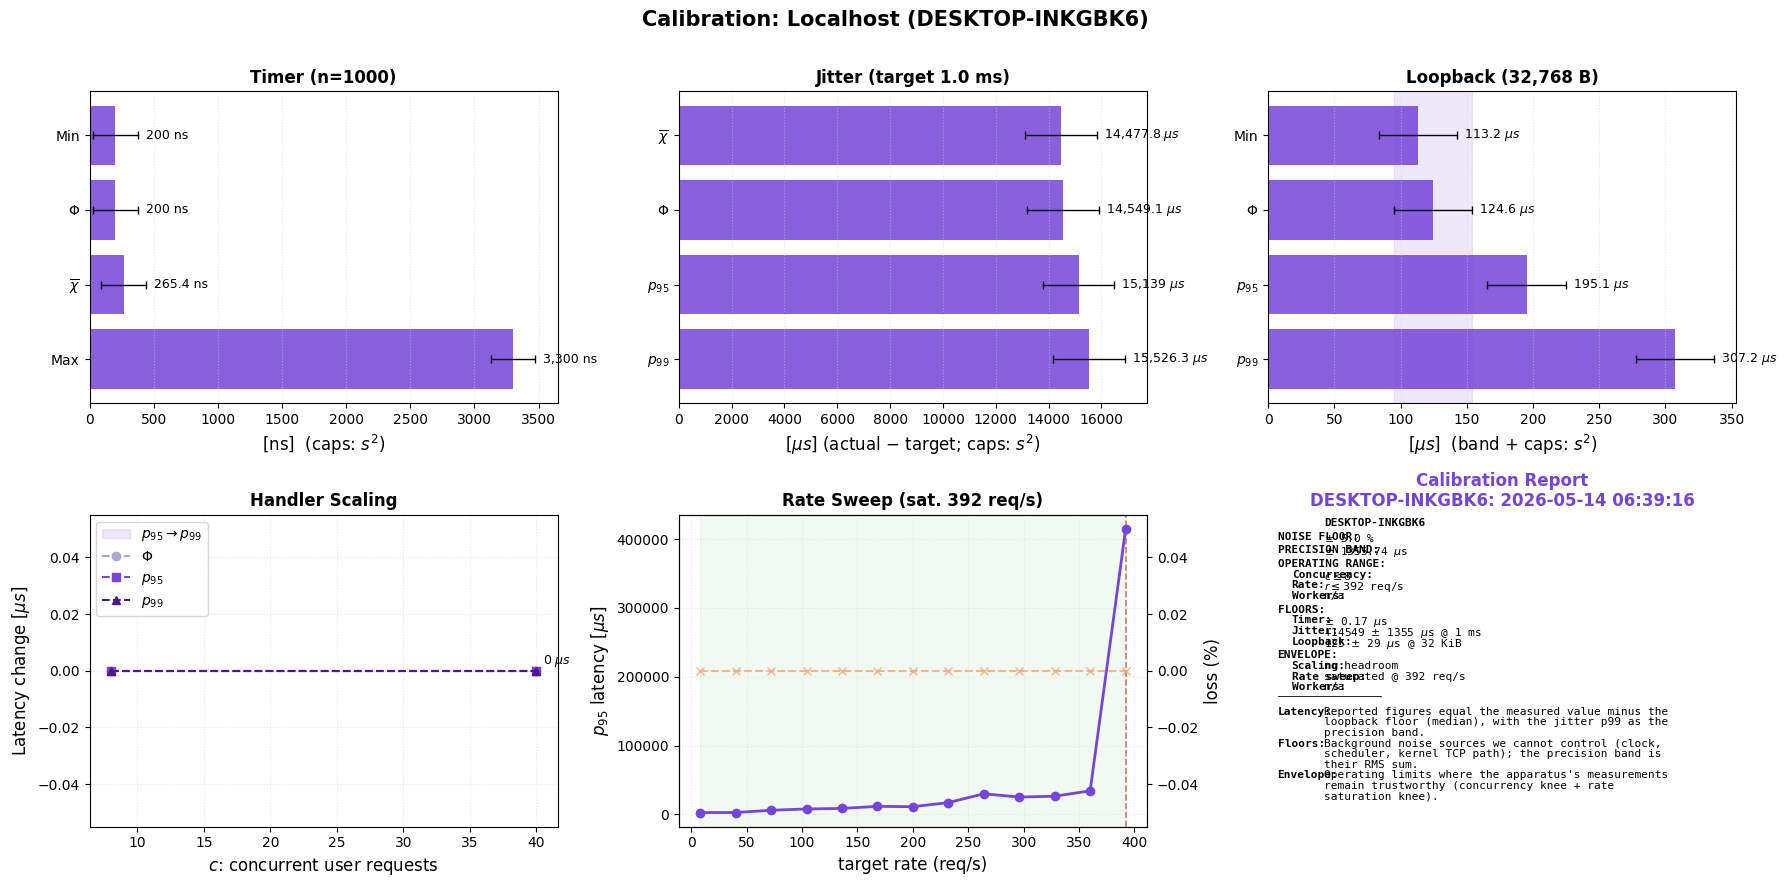

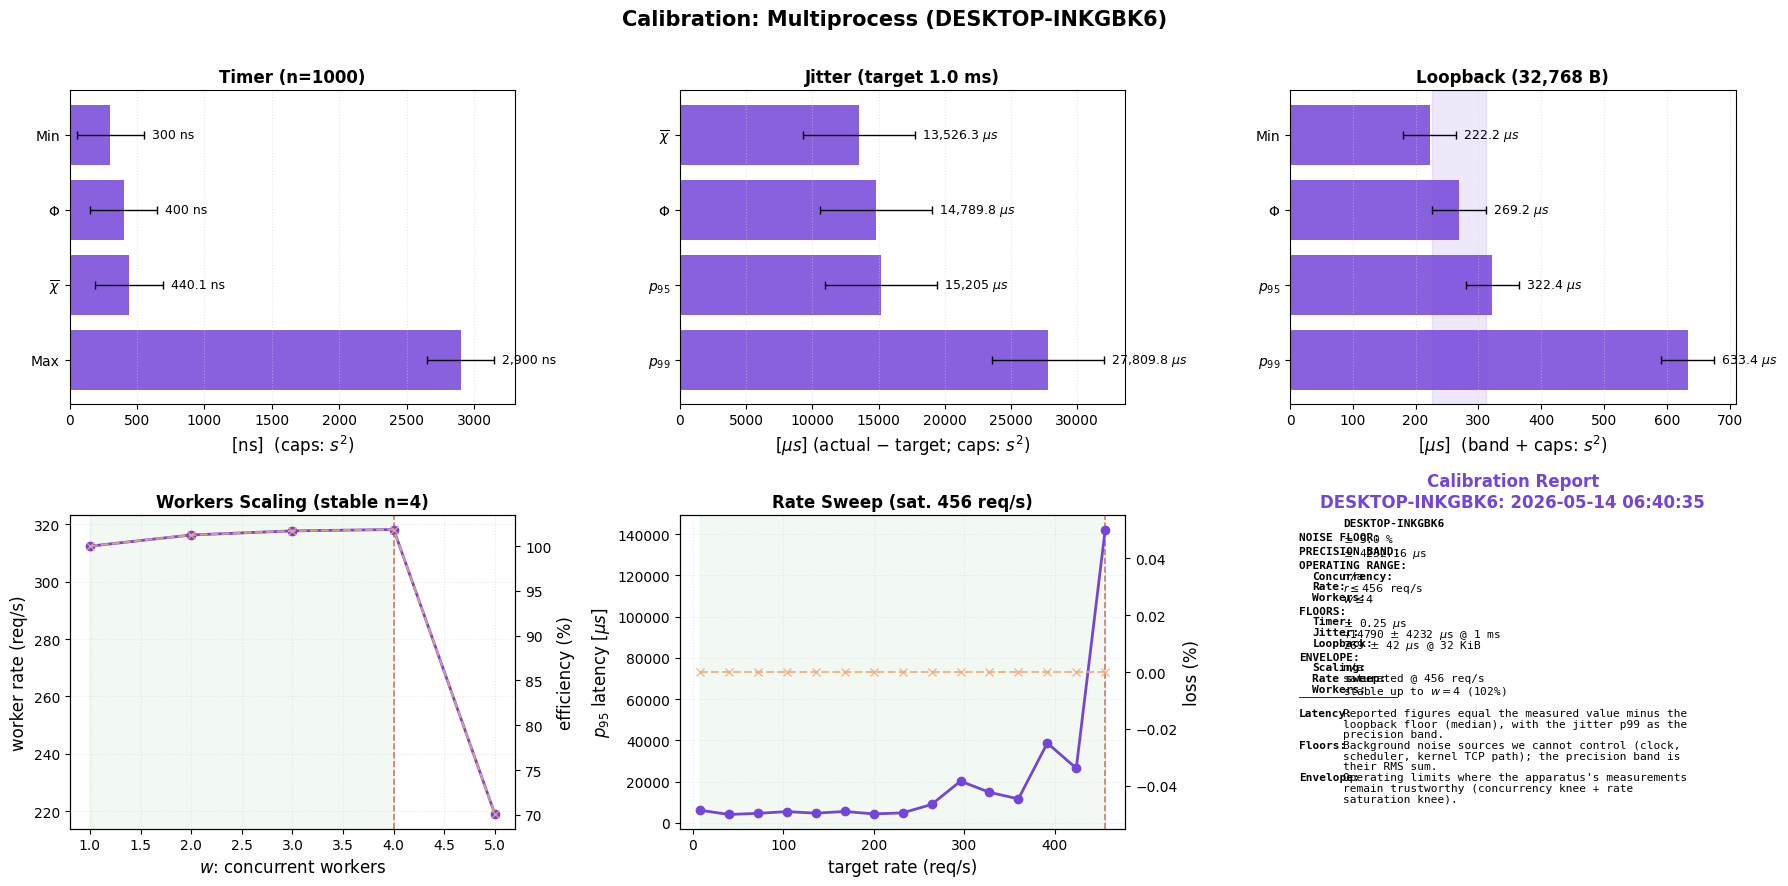

In [4]:
for dpl, env in ENVELOPES.items():
    out_dir = IMG_ROOT / dpl
    title = f"Calibration: {DISPLAY[dpl]} ({env['host']})"
    plot_calibration_summary(env,
                             title=title,
                             file_path=str(out_dir),
                             fname="summary")


## 3. Cross-deployment overlay (headline figure)

Same 2x3 grid with both envelopes overlaid in distinct colours. The dissertation's apparatus-comparison figure: same machine, different deployment shapes, different noise + saturation profiles.


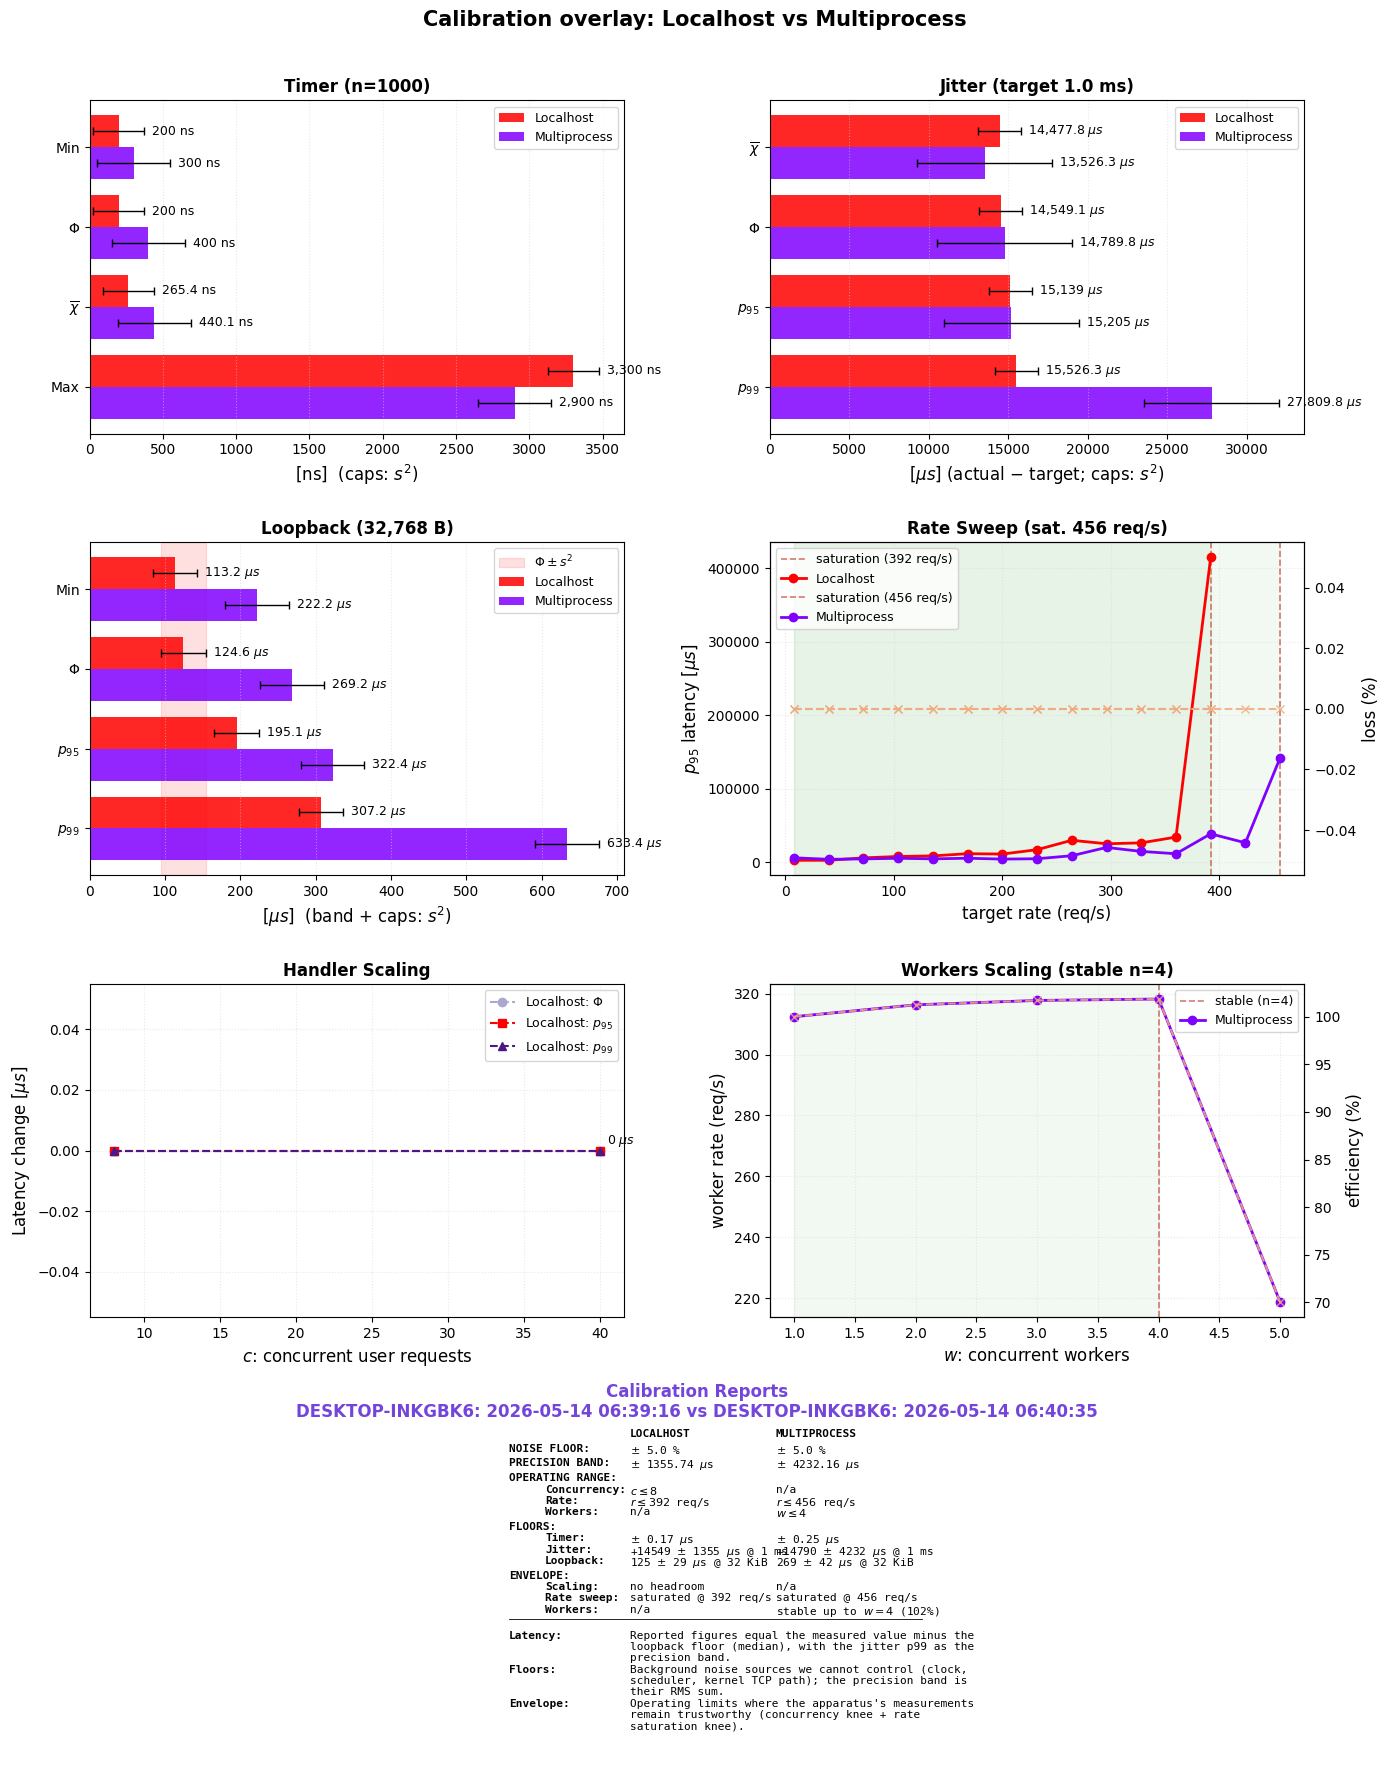

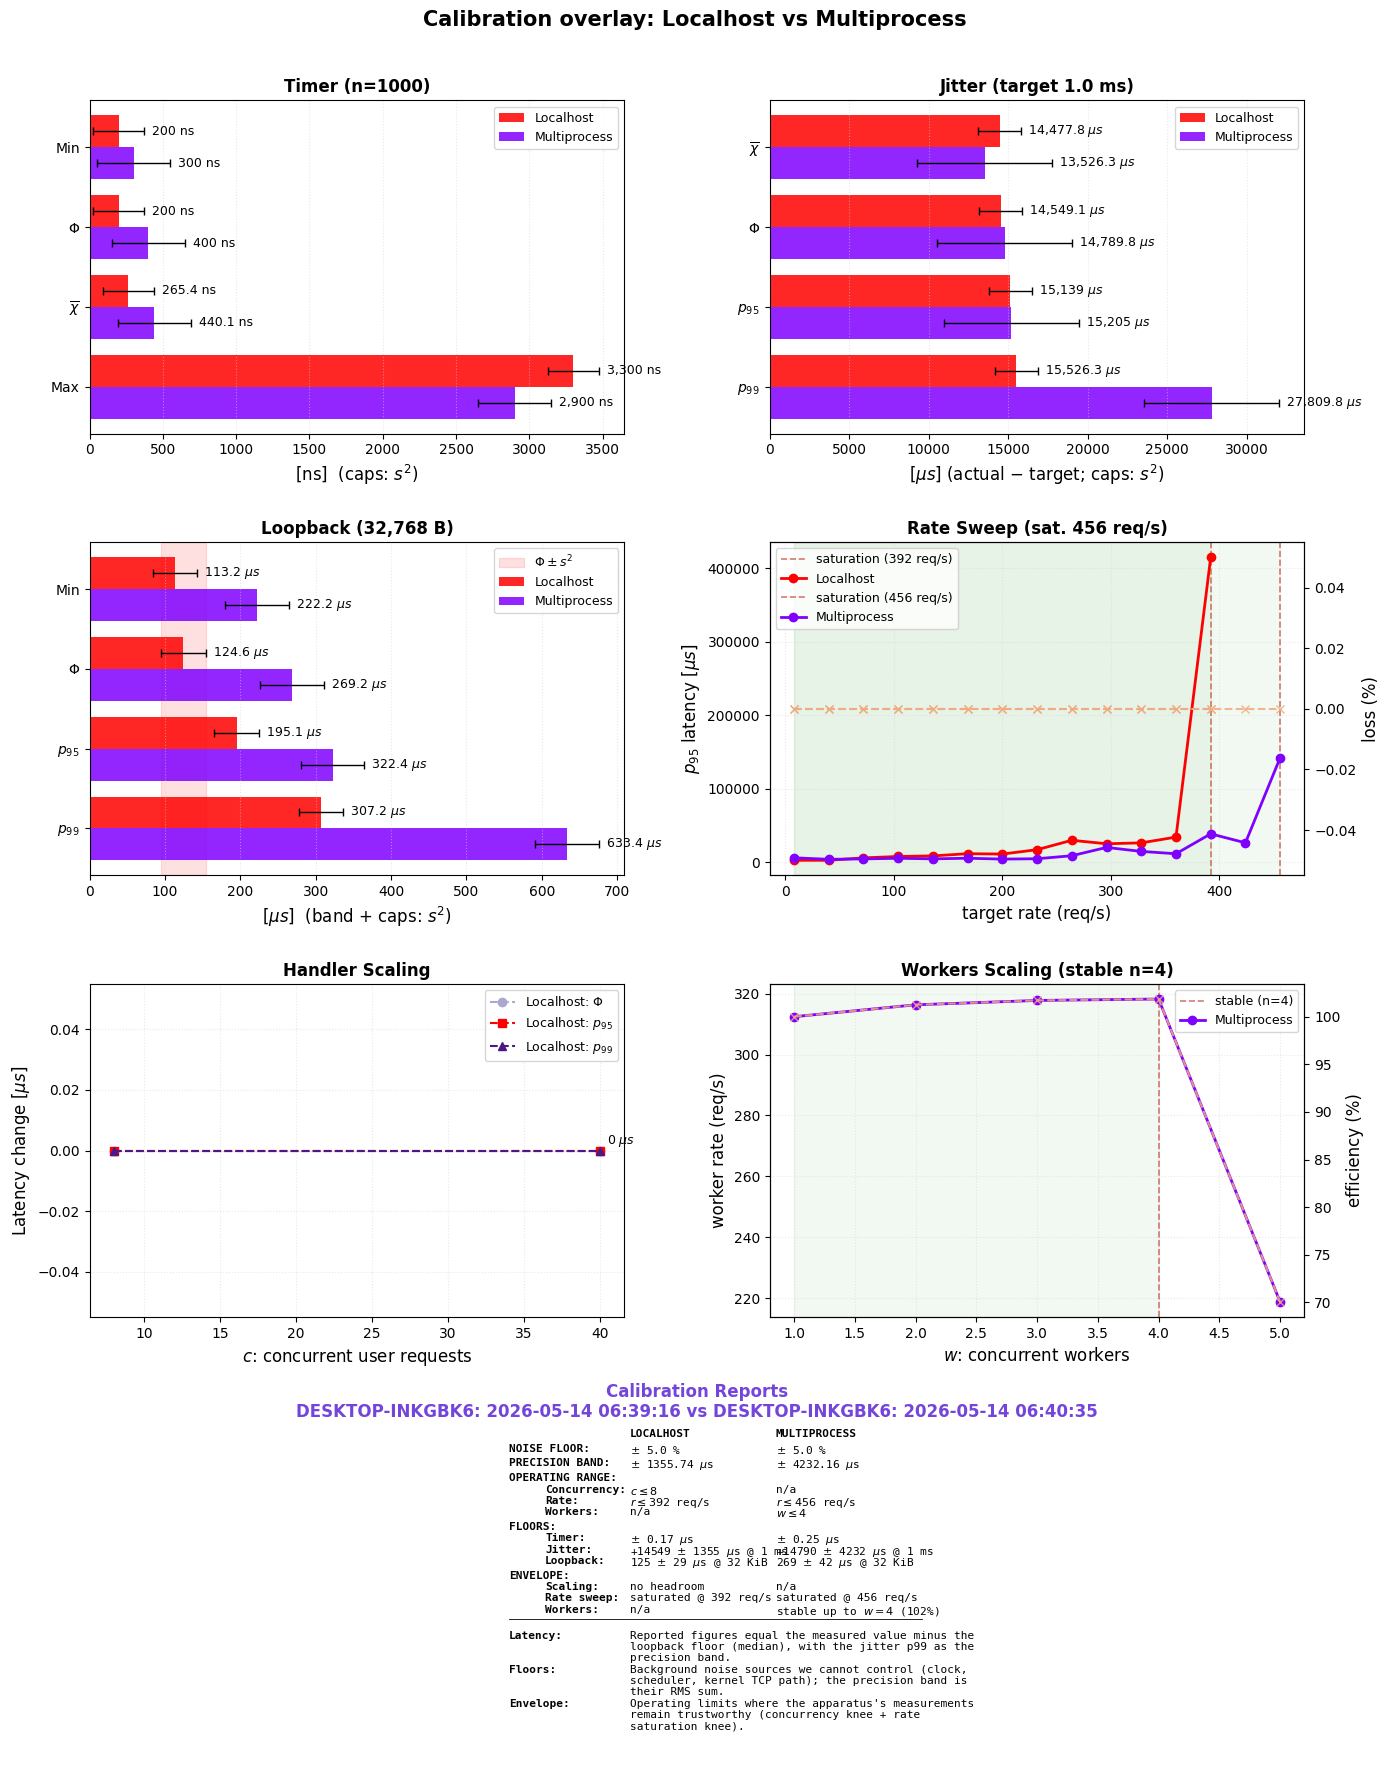

In [5]:
labelled = {DISPLAY[dpl]: env for dpl, env in ENVELOPES.items()}
plot_envelope_overlay(labelled,
                      title="Calibration overlay: Localhost vs Multiprocess",
                      file_path=str(IMG_ROOT / "comparison"),
                      fname="overlay")


## 4. Individual probe panels

Standalone per-probe figures saved alongside the summary so the notebook reader can inspect each probe in isolation. `handler_scaling` only renders for `localhost` runs; `workers_scaling` only for `multiprocess` runs.


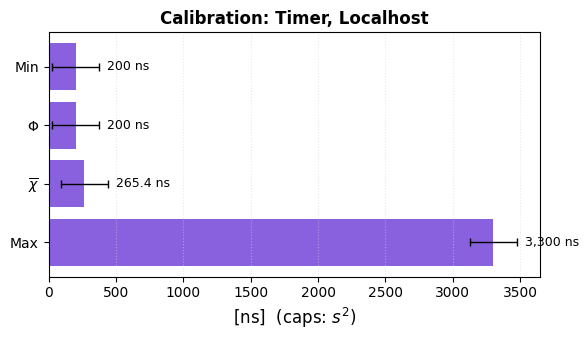

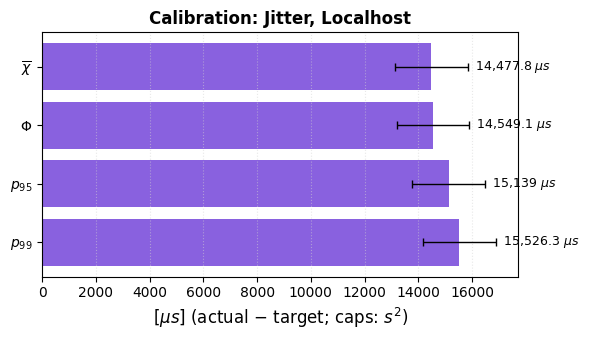

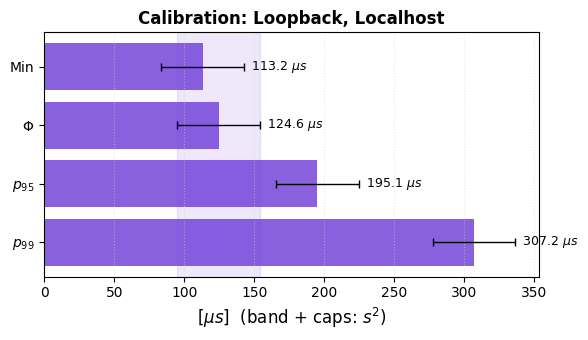

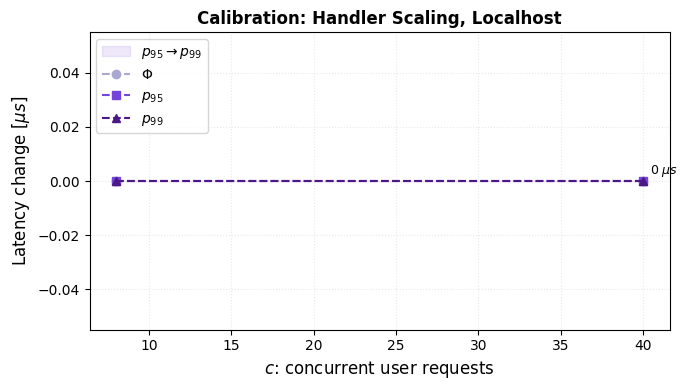

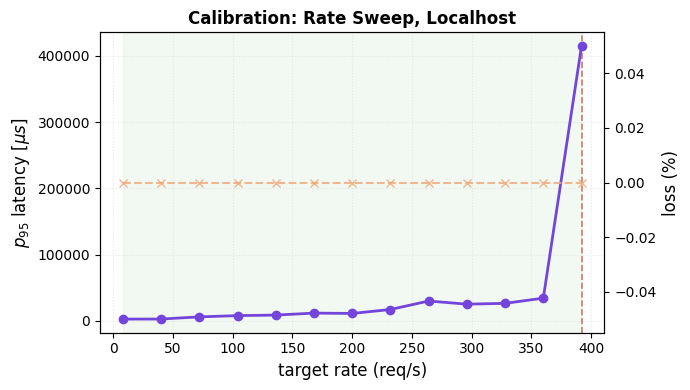

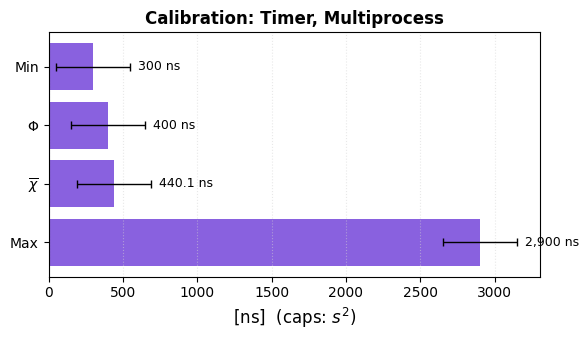

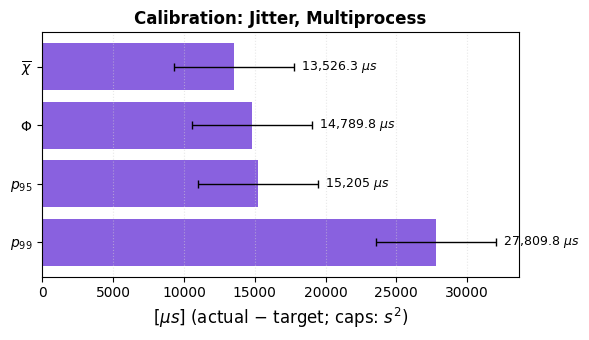

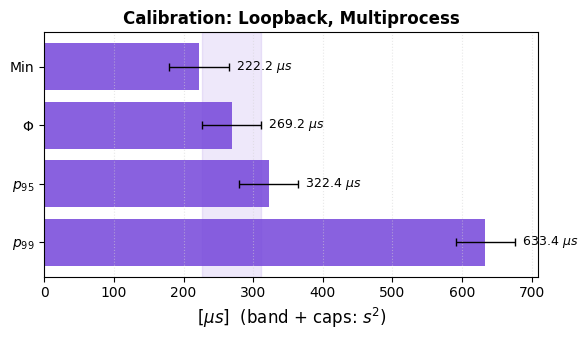

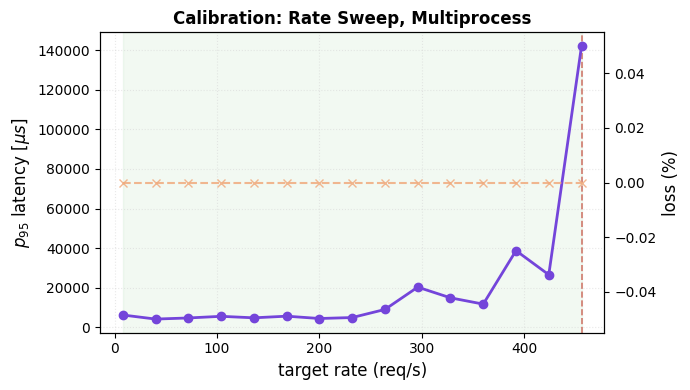

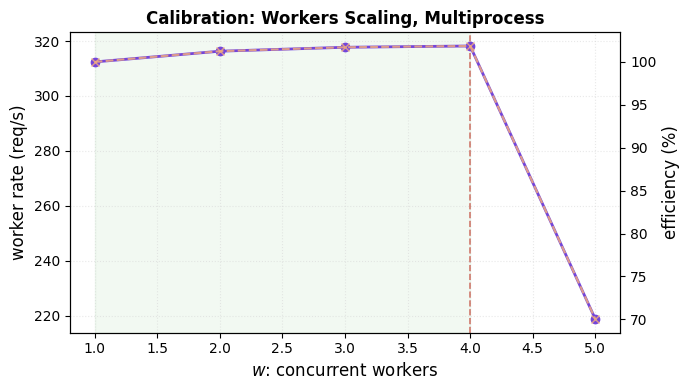

In [6]:
for dpl, env in ENVELOPES.items():
    out_dir = IMG_ROOT / dpl
    scn = DISPLAY[dpl]
    plot_timer(env,
               title=f"Calibration: Timer, {scn}",
               file_path=str(out_dir),
               fname="timer")
    plot_jitter(env,
                title=f"Calibration: Jitter, {scn}",
                file_path=str(out_dir),
                fname="jitter")
    plot_loopback(env,
                  title=f"Calibration: Loopback, {scn}",
                  file_path=str(out_dir),
                  fname="loopback")
    if env.get("handler_scaling"):
        plot_handler_scaling(env,
                             title=f"Calibration: Handler Scaling, {scn}",
                             file_path=str(out_dir),
                             fname="handler_scaling")
    plot_rate_sweep(env,
                    title=f"Calibration: Rate Sweep, {scn}",
                    file_path=str(out_dir),
                    fname="rate_sweep")
    if env.get("workers_scaling"):
        plot_workers_scaling(env,
                             title=f"Calibration: Workers Scaling, {scn}",
                             file_path=str(out_dir),
                             fname="workers_scaling")
